In [1]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
import optax
from flax.core import freeze, unfreeze
import numpy as np
import netket as nk

from netket.graph.common_lattices import Chain
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

print('NetKet version:', nk.__version__)
print("=" * 80)
print(">>> [VMC 终极平滑流水线] Stage 1 (官方 Slater) -> Stage 2 (稠密 AGP+Jastrow) -> Stage 3 (Neural Jastrow)")
print("=" * 80)

# ======================================================================
# 阶段一：官方 Slater 决定式 (无阻力高速收敛)
# ======================================================================
# 直接复用官方，不需要我们自己写模型类，稍后在执行区直接实例化
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        # 直接复用 NetKet 内建 Slater2nd（限制在固定粒子数子空间）
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)
# ======================================================================
# 阶段二：稠密参数化 AGP + 标量 Jastrow (近藤物理激活)
# ======================================================================
class DenseAGPJastrow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # 【核心改进】：抛弃 expm，直接参数化全局 N x N 矩阵！包含参数冗余，优化极度丝滑
        def init_F(key, shape, dtype):
            return jnp.eye(self.n_sites, dtype=dtype)
            
        F_raw = self.param('F_raw', init_F, (self.n_sites, self.n_sites), dtype)
        
        # 强制对称化，保证 S=0 Singlet 结构
        F_matrix = 0.5 * (F_raw + F_raw.T)
        
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
            
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
            
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
            
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_agp = log_det + jnp.log(sign.astype(jnp.complex128))
        
        # 杂质双占惩罚
        g = self.param('impurity_penalty', nn.initializers.constant(5.0), ())
        is_double_occupied = n[..., 0] * n[..., self.n_sites]
        log_jastrow = -g * is_double_occupied.astype(dtype)
        
        return log_agp + log_jastrow

# ======================================================================
# 阶段三：稠密参数化 AGP + 单层 Neural Jastrow (原始基底版)
# ======================================================================
class DenseAGPNeuralJastrow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int
    hidden_dims: tuple = (16,) # 单隐藏层，保留极其关键的单次 GELU 非线性

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # --- 1. AGP 部分 (与阶段二完全相同，保证完美继承) ---
        F_raw = self.param('F_raw', nn.initializers.normal(stddev=0.01), (self.n_sites, self.n_sites), dtype)
        F_matrix = 0.5 * (F_raw + F_raw.T)
        
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_agp = log_det + jnp.log(sign.astype(jnp.complex128))
        
        # --- 2. Neural Jastrow (原始输入，无物理对称约束) ---
        y = x
        for dim in self.hidden_dims:
            y = nn.Dense(features=dim, dtype=dtype)(y)
            y = nn.gelu(y) 
            
        log_neural_jastrow = nn.Dense(features=1, dtype=dtype)(y)
        log_neural_jastrow = jnp.squeeze(log_neural_jastrow, axis=-1)
        
        return log_agp + log_neural_jastrow



C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can use flax.linen, flax.nnx and equinox to define neural networks.

NetKet version: 3.21.1.dev13+gbf43effcb
>>> [VMC 终极平滑流水线] Stage 1 (官方 Slater) -> Stage 2 (稠密 AGP+Jastrow) -> Stage 3 (Neural Jastrow)


chain nodes = 11 , chain edges = 10
n_orbitals = 12
fixed particles (N_up, N_dn) = (6, 6)


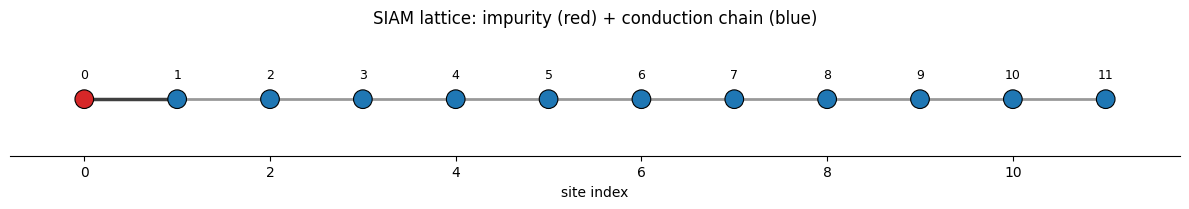

reference E_gs = Not Available (System too large for ED)
sampler graph nodes/edges = 12 11
seeds: (11, 101, 22, 202, 33, 303)


In [2]:
L = 11  # 导带链长度（不含杂质）
chain = Chain(L, pbc=False)
N = chain.n_nodes   # 格点数量，后续会被应用为神经网络的优化参数数量

impurity_site = 0
conduction_offset = 1  # 导带链局部索引 i -> 全局站点 i+1
n_orbitals = L + 1  # 1 个杂质轨道 + L 个导带轨道

if n_orbitals % 2 != 0:
    raise ValueError("n_orbitals 必须为偶数，才能设置 N_up = N_dn = n_orbitals/2")

N_up = n_orbitals // 2
N_dn = n_orbitals // 2

# 在这里直接限制 Hilbert 空间粒子数
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals, s=1 / 2, n_fermions_per_spin=(N_up, N_dn)
 )

print('chain nodes =', chain.n_nodes, ', chain edges =', chain.n_edges)
print('n_orbitals =', n_orbitals)
print('fixed particles (N_up, N_dn) =', (N_up, N_dn))


U = 4.0
V = 0.15
ti = np.ones(L - 1)  # t_i: 导带链上相邻站点之间的 hopping, 长度 L-1

H = 0.0

# 杂质上的库仑相互作用: U (n_d↑ - 1/2)(n_d↓ - 1/2)
n_d_up = nc(hi, impurity_site, sz=+1)
n_d_dn = nc(hi, impurity_site, sz=-1)
H += U * (n_d_up - 0.5) @ (n_d_dn - 0.5)

h_pin = 0.00
H -= h_pin * 0.5 * (n_d_up - n_d_dn)
# 杂质-导带首站点混成: V Σσ (d†σ c0σ + c0†σ dσ)
c0_site = conduction_offset
for sz in (+1, -1):
    H += V * (cdag(hi, impurity_site, sz=sz) @ c(hi, c0_site, sz=sz))
    H += V * (cdag(hi, c0_site, sz=sz) @ c(hi, impurity_site, sz=sz))

# 导带链 hopping: Σσ Σ_i t_i (c†_{iσ} c_{i-1,σ} + h.c.)
# 使用 Chain(L) 的边来确定一维最近邻，局部索引 (0..L-1) 需要偏移到全局站点 (1..L)。
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]

    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset

    for sz in (+1, -1):
        H += t_bond * (cdag(hi, right_site, sz=sz) @ c(hi, left_site, sz=sz))
        H += t_bond * (cdag(hi, left_site, sz=sz) @ c(hi, right_site, sz=sz))

H
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.2))

# 导带内部边（将 chain 的局部索引映射到全局站点 1..L）
for i_local, j_local in chain.edges():
    ax.plot(
        [i_local + conduction_offset, j_local + conduction_offset],
        [0, 0],
        color="0.6",
        lw=2,
        zorder=1,
    )

# 杂质-导带首站点混成边
ax.plot([impurity_site, c0_site], [0, 0], color="0.25", lw=2.5, zorder=2)

# 节点着色：杂质红色，其它导带蓝色
x = np.arange(n_orbitals)
y = np.zeros(n_orbitals)
node_colors = ["tab:red"] + ["tab:blue"] * L
ax.scatter(x, y, c=node_colors, s=180, edgecolors="black", linewidths=0.8, zorder=3)

for site in range(n_orbitals):
    ax.text(site, 0.08, str(site), ha="center", va="bottom", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("site index")
ax.set_title("SIAM lattice: impurity (red) + conduction chain (blue)")
ax.set_xlim(-0.8, n_orbitals - 0.2)
ax.set_ylim(-0.25, 0.3)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
from functools import partial

# ========= Reproducibility seeds =========
SEED_MODEL_SLATER = 11
SEED_SAMPLER_SLATER = 101
SEED_MODEL_NJ = 22
SEED_SAMPLER_NJ = 202
SEED_MODEL_BF = 33
SEED_SAMPLER_BF = 303

# 给采样器构造“空间轨道图”：杂质-首导带 + 导带链最近邻
sampler_edges = [(impurity_site, c0_site)]
sampler_edges += [
    (min(i, j) + conduction_offset, max(i, j) + conduction_offset)
    for (i, j) in chain.edges()
 ]
graph_sampler = nk.graph.Graph(edges=sampler_edges, n_nodes=n_orbitals)

# ==============================================================================
# 体系太大，已彻底移除 ED (Exact Diagonalization) 精确求解部分
# ==============================================================================
E_gs = None 

print("reference E_gs = Not Available (System too large for ED)")
print("sampler graph nodes/edges =", graph_sampler.n_nodes, graph_sampler.n_edges)
print(
    "seeds:",
    (SEED_MODEL_SLATER, SEED_SAMPLER_SLATER, SEED_MODEL_NJ, SEED_SAMPLER_NJ, SEED_MODEL_BF, SEED_SAMPLER_BF),
)

In [ ]:
# ======================================================================
# 【优化器配置】
# ======================================================================
def get_optimizer_and_sr(steps=300):
    lr_schedule = optax.cosine_decay_schedule(init_value=0.005, decay_steps=steps, alpha=0.01)
    op = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(learning_rate=lr_schedule, b1=0.8, b2=0.999, eps=1e-8))
    sr_shift = optax.linear_schedule(init_value=0.05, end_value=0.001, transition_steps=int(steps*0.6))
    sr = nk.optimizer.SR(diag_shift=sr_shift, solver=nk.optimizer.solver.pinv, holomorphic=False, qgt=nk.optimizer.qgt.QGTJacobianDense)
    return op, sr

# 假设外部环境已定义 hi, H, graph_sampler, n_orbitals, N_up, N_dn
N_ITER = 300
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler)

# ======================================================================
# >>> Stage 1: 官方 Slater2nd (极速寻找平均场轨道)
# ======================================================================
print("\n" + "-" * 80)
print(">>> [Stage 1/3] 正在训练 官方 Slater2nd...")
model_1 = nk.models.Slater2nd(hilbert=hi, restricted=True, generalized=False, param_dtype=float)
vs_1 = nk.vqs.MCState(sampler=sa, model=model_1, n_samples=2**12, n_discard_per_chain=32)
op_1, sr_1 = get_optimizer_and_sr(N_ITER)
gs_1 = nk.VMC(hamiltonian=H, optimizer=op_1, preconditioner=sr_1, variational_state=vs_1)
log_1 = nk.logging.RuntimeLog()  # 【修改点 1】：实例化并保存日志对象
gs_1.run(n_iter=N_ITER, out=log_1)
print(f"[Stage 1 完] 官方 RHF 能量: {vs_1.expect(H).mean.real:.6f}")

# ======================================================================
# >>> Stage 2: 稠密 AGP + Jastrow (完美数学桥接)
# ======================================================================
print("\n" + "-" * 80)
print(">>> [Stage 2/3] 正在训练 稠密 AGP + Jastrow (解析矩阵继承)...")
model_2 = DenseAGPJastrow(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn)
vs_2 = nk.vqs.MCState(sampler=sa, model=model_2, n_samples=2**12, n_discard_per_chain=32)

# 【核心炼丹术】：从 Slater M 矩阵解析构造 AGP F 矩阵
# 获取普通字典形式的参数（兼容不同版本的 Flax/NetKet）
params_2 = unfreeze(vs_2.parameters) if hasattr(vs_2.parameters, 'unfreeze') else dict(vs_2.parameters)

M_matrix = vs_1.parameters['M'] # 形状 (N_sites, N_up)
F_init = jnp.dot(M_matrix, M_matrix.T) # F_init = M * M^T，精准等价

params_2['F_raw'] = F_init

# 直接把字典赋回去，千万别加 freeze() ！
vs_2.parameters = params_2
print(" [+] 成功利用 Cauchy-Binet 定理继承: M -> F_raw (解析等价构建)")

op_2, sr_2 = get_optimizer_and_sr(N_ITER)
gs_2 = nk.VMC(hamiltonian=H, optimizer=op_2, preconditioner=sr_2, variational_state=vs_2)
log_2 = nk.logging.RuntimeLog()  # 【修改点 1】：实例化并保存日志对象
gs_2.run(n_iter=N_ITER, out=log_2)
print(f"[Stage 2 完] 稠密 AGP+Jastrow 能量: {vs_2.expect(H).mean.real:.6f}")

# ======================================================================
# >>> Stage 3: 稠密 AGP + Neural Jastrow (释放非线性)
# ======================================================================
print("\n" + "-" * 80)
print(">>> [Stage 3/3] 正在训练 稠密 AGP + 单层 Neural Jastrow...")
model_2 = DenseAGPNeuralJastrow(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn)
vs_2 = nk.vqs.MCState(sampler=sa, model=model_2, n_samples=2**12, n_discard_per_chain=32)

# 获取并复制 Stage 3 的参数字典
params_2 = unfreeze(vs_2.parameters) if hasattr(vs_2.parameters, 'unfreeze') else dict(vs_2.parameters)

# 直接继承 Stage 2 已经优化好的配对矩阵
params_2['F_raw'] = vs_2.parameters['F_raw'] 

# 同样，直接赋值，不加 freeze()
vs_2.parameters = params_2
print(" [+] 成功从 Stage 2 继承稠密配对矩阵: F_raw")
print(" [+] 神经网络权重随机初始化完毕")

op_2, sr_2 = get_optimizer_and_sr(N_ITER)
gs_2 = nk.VMC(hamiltonian=H, optimizer=op_2, preconditioner=sr_2, variational_state=vs_2)
log_2 = nk.logging.RuntimeLog()  # 【修改点 1】：实例化并保存日志对象
gs_2.run(n_iter=N_ITER, out=log_2)
print(f"[Stage 3 完] 最终终极基态能量: {vs_2.expect(H).mean.real:.6f}")
print("=" * 80)


--------------------------------------------------------------------------------
>>> [Stage 1/3] 正在训练 官方 Slater2nd...


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [05:51<00:00,  1.17s/it, Energy=-13.356-0.000j ± 0.020 [σ²=1.0e+00, R̂=1.003]]


[Stage 1 完] 官方 RHF 能量: -13.339364

--------------------------------------------------------------------------------
>>> [Stage 2/3] 正在训练 稠密 AGP + Jastrow (解析矩阵继承)...
 [+] 成功利用 Cauchy-Binet 定理继承: M -> F_raw (解析等价构建)


100%|██████████| 300/300 [02:07<00:00,  2.34it/s, Energy=-10.707+0.000j ± 0.031 [σ²=2.1e+00, R̂=1.012]]  


[Stage 2 完] 稠密 AGP+Jastrow 能量: -10.730239

--------------------------------------------------------------------------------
>>> [Stage 3/3] 正在训练 稠密 AGP + 单层 Neural Jastrow...
 [+] 成功从 Stage 2 继承稠密配对矩阵: F_raw
 [+] 神经网络权重随机初始化完毕


100%|██████████| 300/300 [03:39<00:00,  1.37it/s, Energy=-12.949+0.000j ± 0.021 [σ²=7.5e-01, R̂=1.018]]


[Stage 3 完] 最终终极基态能量: -12.888661


正在绘制能量收敛曲线...


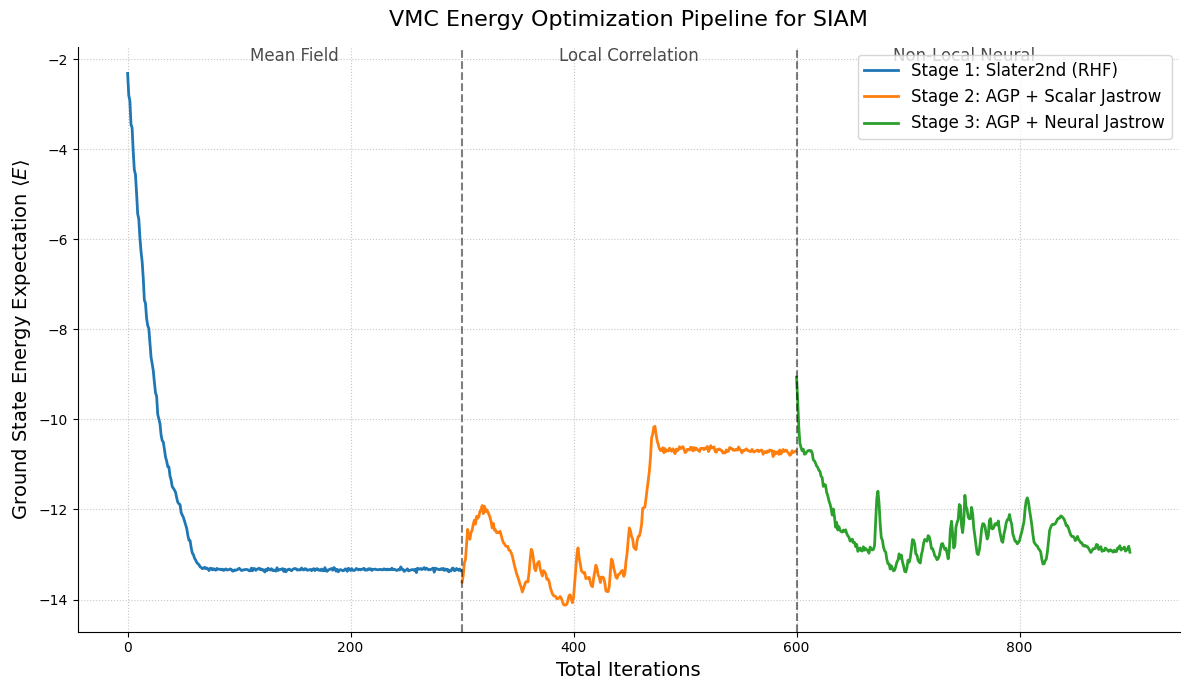

In [13]:
# ======================================================================
# 【绘图模块】: 三阶段能量下降全景图
# ======================================================================
print("正在绘制能量收敛曲线...")

# 极度安全、兼容所有 NetKet 版本的能量提取函数
def extract_energy_and_iters(log_obj):
    hist = log_obj.data["Energy"]
    iters = np.array(hist.iters)
    
    # 尝试多种可能的提取方式 (应对底层字典属性映射差异)
    if hasattr(hist, "Mean"):
        energy = np.real(hist.Mean)
    elif hasattr(hist, "mean"):
        energy = np.real(hist.mean)
    elif hasattr(hist, "values"):
        # 如果是原始列表，逐个检查提取
        energy = np.array([x.mean.real if hasattr(x, 'mean') else np.real(x) for x in hist.values])
    else:
        # 终极 Fallback
        energy = np.array([np.real(x) for x in hist])
        
    return iters, energy

# 提取并自动处理三种可能的数据结构
iters_1, energy_1 = extract_energy_and_iters(log_1)
iters_2, energy_2 = extract_energy_and_iters(log_2)
iters_3, energy_3 = extract_energy_and_iters(log_3)

# 把第二、三阶段的步数向后平移，拼成连续的时间线
iters_2 = iters_2 + N_ITER
iters_3 = iters_3 + 2 * N_ITER

# 开始画图
plt.figure(figsize=(12, 7))

# 画三条连续的曲线，用不同的颜色标识
plt.plot(iters_1, energy_1, label='Stage 1: Slater2nd (RHF)', color='tab:blue', linewidth=2)
plt.plot(iters_2, energy_2, label='Stage 2: AGP + Scalar Jastrow', color='tab:orange', linewidth=2)
plt.plot(iters_3, energy_3, label='Stage 3: AGP + Neural Jastrow', color='tab:green', linewidth=2)

# 画垂直分割线，标明过渡点
plt.axvline(x=N_ITER, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=2*N_ITER, color='k', linestyle='--', alpha=0.5)

# 添加阶段文本标注
plt.text(N_ITER/2, plt.ylim()[1], 'Mean Field', horizontalalignment='center', verticalalignment='top', fontsize=12, alpha=0.7)
plt.text(N_ITER + N_ITER/2, plt.ylim()[1], 'Local Correlation', horizontalalignment='center', verticalalignment='top', fontsize=12, alpha=0.7)
plt.text(2*N_ITER + N_ITER/2, plt.ylim()[1], 'Non-Local Neural', horizontalalignment='center', verticalalignment='top', fontsize=12, alpha=0.7)

# 图表美化
plt.title("VMC Energy Optimization Pipeline for SIAM", fontsize=16, pad=15)
plt.xlabel("Total Iterations", fontsize=14)
plt.ylabel("Ground State Energy Expectation $\\langle E \\rangle$", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12, loc='upper right')

# 移除上右边框使图表更清爽
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
# ======================================================================
# 阶段二：防爆版 AGP + 标量 Jastrow (Tanh 冗余控制)
# ======================================================================
class SafeAGPJastrow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # 1. 声明冗余参数 W (N x N)
        W = self.param('W', nn.initializers.normal(stddev=0.01), (self.n_sites, self.n_sites), dtype)
        
        # 2. 【核心防爆盾】：强迫对称，并用 tanh 限制元素范围在 [-1, 1] 之间
        F_matrix = jnp.tanh(W + W.T)
        
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
            
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
            
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
            
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_agp = log_det + jnp.log(sign.astype(jnp.complex128))
        
        # 杂质双占惩罚
        g = self.param('impurity_penalty', nn.initializers.constant(5.0), ())
        is_double_occupied = n[..., 0] * n[..., self.n_sites]
        log_jastrow = -g * is_double_occupied.astype(dtype)
        
        return log_agp + log_jastrow

# ======================================================================
# 阶段三：防爆版 AGP + 单层 Neural Jastrow
# ======================================================================
class SafeAGPNeuralJastrow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int
    hidden_dims: tuple = (16,) 

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # --- 1. AGP 部分 (保持防爆结构) ---
        W = self.param('W', nn.initializers.normal(stddev=0.01), (self.n_sites, self.n_sites), dtype)
        F_matrix = jnp.tanh(W + W.T)
        
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_agp = log_det + jnp.log(sign.astype(jnp.complex128))
        
        # --- 2. Neural Jastrow ---
        y = x
        for dim in self.hidden_dims:
            y = nn.Dense(features=dim, dtype=dtype)(y)
            y = nn.gelu(y) 
            
        log_neural_jastrow = nn.Dense(features=1, dtype=dtype)(y)
        log_neural_jastrow = jnp.squeeze(log_neural_jastrow, axis=-1)
        
        return log_agp + log_neural_jastrow

In [21]:
# ======================================================================
# 【优化器配置】
# ======================================================================
def get_optimizer_and_sr(steps=300):
    lr_schedule = optax.cosine_decay_schedule(init_value=0.005, decay_steps=steps, alpha=0.01)
    op = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(learning_rate=lr_schedule, b1=0.8, b2=0.999, eps=1e-8))
    sr_shift = optax.linear_schedule(init_value=0.05, end_value=0.001, transition_steps=int(steps*0.6))
    sr = nk.optimizer.SR(diag_shift=sr_shift, solver=nk.optimizer.solver.pinv, holomorphic=False, qgt=nk.optimizer.qgt.QGTJacobianDense)
    return op, sr

# 假设外部环境已定义 hi, H, graph_sampler, n_orbitals, N_up, N_dn
N_ITER = 300
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler)

# ======================================================================
# >>> Stage 1: 官方 Slater2nd (极速寻找平均场轨道)
# ======================================================================
print("\n" + "-" * 80)
print(">>> [Stage 1/3] 正在训练 官方 Slater2nd...")
model_1 = nk.models.Slater2nd(hilbert=hi, restricted=True, generalized=False, param_dtype=float)
vs_1 = nk.vqs.MCState(sampler=sa, model=model_1, n_samples=2**12, n_discard_per_chain=32)
op_1, sr_1 = get_optimizer_and_sr(N_ITER)
gs_1 = nk.VMC(hamiltonian=H, optimizer=op_1, preconditioner=sr_1, variational_state=vs_1)
log_1 = nk.logging.RuntimeLog()  # 【修改点 1】：实例化并保存日志对象
gs_1.run(n_iter=N_ITER, out=log_1)
print(f"[Stage 1 完] 官方 RHF 能量: {vs_1.expect(H).mean.real:.6f}")


# --- 在 Stage 2 训练前的参数继承部分替换为：---
model_3 = SafeAGPJastrow(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn)
vs_3 = nk.vqs.MCState(sampler=sa, model=model_3, n_samples=2**12, n_discard_per_chain=32)

params_3 = unfreeze(vs_3.parameters) if hasattr(vs_3.parameters, 'unfreeze') else dict(vs_3.parameters)
M_matrix = vs_1.parameters['M'] # 形状 (N_sites, N_up)
F_init_raw = jnp.dot(M_matrix, M_matrix.T) 

# 【核心炼丹术】：缩放不变性 + arctanh 逆映射
# 1. 找到矩阵中的最大绝对值
max_val = jnp.max(jnp.abs(F_init_raw))
# 2. 将矩阵安全地等比例缩放到 [-0.8, 0.8] 之间
F_init_scaled = (F_init_raw / max_val) * 0.8
# 3. 求解初始的 W 参数 (因为 F = tanh(2W)，所以 W = 0.5 * arctanh(F))
W_init = 0.5 * jnp.arctanh(F_init_scaled)

params_3['W'] = W_init
vs_3.parameters = params_3
print(" [+] 成功利用缩放不变性 + arctanh 继承参数，防爆护盾已激活！")
op_3, sr_3 = get_optimizer_and_sr(N_ITER)
gs_3 = nk.VMC(hamiltonian=H, optimizer=op_3, preconditioner=sr_3, variational_state=vs_3)
log_3 = nk.logging.RuntimeLog()  # 【修改点 1】：实例化并保存日志对象
gs_3.run(n_iter=N_ITER, out=log_3)
print(f"[Stage 2 完] 稠密tanh AGP+Jastrow 能量: {vs_3.expect(H).mean.real:.6f}")


--------------------------------------------------------------------------------
>>> [Stage 1/3] 正在训练 官方 Slater2nd...


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [02:12<00:00,  2.26it/s, Energy=-13.092-0.000j ± 0.030 [σ²=1.0e+00, R̂=1.027]]


[Stage 1 完] 官方 RHF 能量: -13.051091
 [+] 成功利用缩放不变性 + arctanh 继承参数，防爆护盾已激活！


100%|██████████| 300/300 [02:34<00:00,  1.95it/s, Energy=-12.221-0.000j ± 0.045 [σ²=3.3e+00, R̂=1.026]]


[Stage 2 完] 稠密tanh AGP+Jastrow 能量: -12.204108


In [26]:
# ======================================================================
# 阶段二 & 三通用的 AGP 核心模块 (Factorized Redundancy 版)
# ======================================================================
class SmoothAGPJastrow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # 1. 声明极度冗余的稠密矩阵 A (N x N)
        A = self.param('A', nn.initializers.normal(stddev=0.01), (self.n_sites, self.n_sites), dtype)
        
        # 2. 构造固定的物理符号矩阵 (Signature Matrix)
        # 前 n_up 个为 1 (占据态)，后 n_sites - n_up 个为 -1 (虚态)
        sig = jnp.concatenate([jnp.ones(self.n_up), -jnp.ones(self.n_sites - self.n_up)])
        
        # 3. 【核心冗余映射】：F = A * Sigma * A^T
        # 纯粹的矩阵乘法，绝对平滑，无 tanh 饱和，无 expm 扭曲！
        F_matrix = jnp.dot(A * sig, A.T)
        
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
            
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_agp = log_det + jnp.log(sign.astype(jnp.complex128))
        
        # 杂质双占惩罚
        g = self.param('impurity_penalty', nn.initializers.constant(5.0), ())
        is_double_occupied = n[..., 0] * n[..., self.n_sites]
        log_jastrow = -g * is_double_occupied.astype(dtype)
        
        return log_agp + log_jastrow
    # ======================================================================
# 阶段三：防爆版 AGP + 单层 Neural Jastrow
# ======================================================================
class SmoothAGPNeuralJastrow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int
    hidden_dims: tuple = (16,) 

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # 1. 声明极度冗余的稠密矩阵 A (N x N)
        A = self.param('A', nn.initializers.normal(stddev=0.01), (self.n_sites, self.n_sites), dtype)
        
        # 2. 构造固定的物理符号矩阵 (Signature Matrix)
        # 前 n_up 个为 1 (占据态)，后 n_sites - n_up 个为 -1 (虚态)
        sig = jnp.concatenate([jnp.ones(self.n_up), -jnp.ones(self.n_sites - self.n_up)])
        
        # 3. 【核心冗余映射】：F = A * Sigma * A^T
        # 纯粹的矩阵乘法，绝对平滑，无 tanh 饱和，无 expm 扭曲！
        F_matrix = jnp.dot(A * sig, A.T)
        
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
            
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_agp = log_det + jnp.log(sign.astype(jnp.complex128))
        
        # --- 2. Neural Jastrow ---
        y = x
        for dim in self.hidden_dims:
            y = nn.Dense(features=dim, dtype=dtype)(y)
            y = nn.gelu(y) 
            
        log_neural_jastrow = nn.Dense(features=1, dtype=dtype)(y)
        log_neural_jastrow = jnp.squeeze(log_neural_jastrow, axis=-1)
        
        return log_agp + log_neural_jastrow

# (Stage 3 的 Neural Jastrow 版本只需在末尾加上 MLP，前面 AGP 构建方式与上面完全一致)

In [25]:
model_5 = SmoothAGPJastrow(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn)
vs_5 = nk.vqs.MCState(sampler=sa, model=model_5, n_samples=2**12, n_discard_per_chain=32)

params_5 = unfreeze(vs_5.parameters) if hasattr(vs_5.parameters, 'unfreeze') else dict(vs_5.parameters)

M_matrix = vs_1.parameters['M'] # Stage 1 收敛的矩阵，形状 (N, N_up)

# 初始化一个空的 N x N 矩阵 A
import numpy as np
A_init = np.zeros((n_orbitals, n_orbitals))

# 【核心】：将 RHF 的占据轨道直接塞进 A 的前 N_up 列！
A_init[:, :N_up] = np.array(M_matrix)

# 【唤醒冗余】：给后面的虚轨道加一点极微小的噪声，打破对称性，让优化器有梯度可走
noise = np.random.normal(0, 0.001, (n_orbitals, n_orbitals - N_up))
A_init[:, N_up:] = noise

params_5['A'] = jnp.array(A_init)
vs_5.parameters = params_5
print(" [+] 成功激活不定因子冗余 (Factorized Redundancy)，RHF 态完美继承！")
op_5, sr_5 = get_optimizer_and_sr(N_ITER)
gs_5 = nk.VMC(hamiltonian=H, optimizer=op_5, preconditioner=sr_5, variational_state=vs_5)
log_5 = nk.logging.RuntimeLog()  # 【修改点 1】：实例化并保存日志对象
gs_5.run(n_iter=N_ITER, out=log_5)
print(f"[Stage 2 完] 稠密tanh AGP+Jastrow 能量: {vs_5.expect(H).mean.real:.6f}")

 [+] 成功激活不定因子冗余 (Factorized Redundancy)，RHF 态完美继承！


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [02:19<00:00,  2.16it/s, Energy=-13.461+0.000j ± 0.014 [σ²=3.0e-01, R̂=1.018]]      


[Stage 2 完] 稠密tanh AGP+Jastrow 能量: -13.406321


In [27]:
model_6 = SmoothAGPNeuralJastrow(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn)
vs_6 = nk.vqs.MCState(sampler=sa, model=model_6, n_samples=2**12, n_discard_per_chain=32)

params_6 = unfreeze(vs_6.parameters) if hasattr(vs_6.parameters, 'unfreeze') else dict(vs_6.parameters)

M_matrix = vs_1.parameters['M'] # Stage 1 收敛的矩阵，形状 (N, N_up)

# 初始化一个空的 N x N 矩阵 A
import numpy as np
A_init = np.zeros((n_orbitals, n_orbitals))

# 【核心】：将 RHF 的占据轨道直接塞进 A 的前 N_up 列！
A_init[:, :N_up] = np.array(M_matrix)

# 【唤醒冗余】：给后面的虚轨道加一点极微小的噪声，打破对称性，让优化器有梯度可走
noise = np.random.normal(0, 0.001, (n_orbitals, n_orbitals - N_up))
A_init[:, N_up:] = noise

params_6['A'] = jnp.array(A_init)
vs_6.parameters = params_6
print(" [+] 成功激活不定因子冗余 (Factorized Redundancy)，RHF 态完美继承！")
op_6, sr_6 = get_optimizer_and_sr(N_ITER)
gs_6 = nk.VMC(hamiltonian=H, optimizer=op_6, preconditioner=sr_6, variational_state=vs_6)
log_6 = nk.logging.RuntimeLog()  # 【修改点 1】：实例化并保存日志对象
gs_6.run(n_iter=N_ITER, out=log_6)
print(f"[Stage 2 完] 稠密tanh AGP+Jastrow 能量: {vs_6.expect(H).mean.real:.6f}")

 [+] 成功激活不定因子冗余 (Factorized Redundancy)，RHF 态完美继承！


100%|██████████| 300/300 [02:56<00:00,  1.70it/s, Energy=-14.0980+0.0000j ± 0.0062 [σ²=1.2e-01, R̂=1.003]]


[Stage 2 完] 稠密tanh AGP+Jastrow 能量: -14.102231


正在绘制能量收敛曲线...


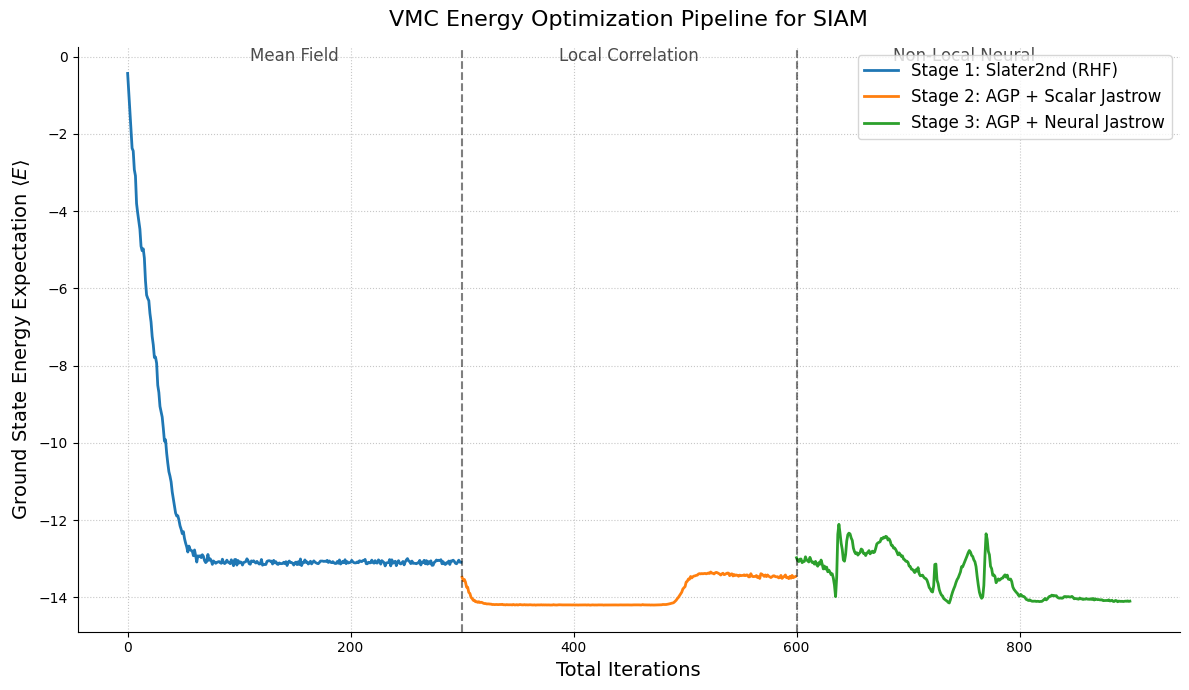

In [28]:
# ======================================================================
# 【绘图模块】: 三阶段能量下降全景图
# ======================================================================
print("正在绘制能量收敛曲线...")

# 极度安全、兼容所有 NetKet 版本的能量提取函数
def extract_energy_and_iters(log_obj):
    hist = log_obj.data["Energy"]
    iters = np.array(hist.iters)
    
    # 尝试多种可能的提取方式 (应对底层字典属性映射差异)
    if hasattr(hist, "Mean"):
        energy = np.real(hist.Mean)
    elif hasattr(hist, "mean"):
        energy = np.real(hist.mean)
    elif hasattr(hist, "values"):
        # 如果是原始列表，逐个检查提取
        energy = np.array([x.mean.real if hasattr(x, 'mean') else np.real(x) for x in hist.values])
    else:
        # 终极 Fallback
        energy = np.array([np.real(x) for x in hist])
        
    return iters, energy

# 提取并自动处理三种可能的数据结构
iters_1, energy_1 = extract_energy_and_iters(log_1)
iters_5, energy_5 = extract_energy_and_iters(log_5)
iters_6, energy_6 = extract_energy_and_iters(log_6)

# 把第二、三阶段的步数向后平移，拼成连续的时间线
iters_5 = iters_5 + N_ITER
iters_6 = iters_6 + 2 * N_ITER

# 开始画图
plt.figure(figsize=(12, 7))

# 画三条连续的曲线，用不同的颜色标识
plt.plot(iters_1, energy_1, label='Stage 1: Slater2nd (RHF)', color='tab:blue', linewidth=2)
plt.plot(iters_5, energy_5, label='Stage 2: AGP + Scalar Jastrow', color='tab:orange', linewidth=2)
plt.plot(iters_6, energy_6, label='Stage 3: AGP + Neural Jastrow', color='tab:green', linewidth=2)

# 画垂直分割线，标明过渡点
plt.axvline(x=N_ITER, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=2*N_ITER, color='k', linestyle='--', alpha=0.5)

# 添加阶段文本标注
plt.text(N_ITER/2, plt.ylim()[1], 'Mean Field', horizontalalignment='center', verticalalignment='top', fontsize=12, alpha=0.7)
plt.text(N_ITER + N_ITER/2, plt.ylim()[1], 'Local Correlation', horizontalalignment='center', verticalalignment='top', fontsize=12, alpha=0.7)
plt.text(2*N_ITER + N_ITER/2, plt.ylim()[1], 'Non-Local Neural', horizontalalignment='center', verticalalignment='top', fontsize=12, alpha=0.7)

# 图表美化
plt.title("VMC Energy Optimization Pipeline for SIAM", fontsize=16, pad=15)
plt.xlabel("Total Iterations", fontsize=14)
plt.ylabel("Ground State Energy Expectation $\\langle E \\rangle$", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12, loc='upper right')

# 移除上右边框使图表更清爽
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
print("\n" + "-" * 80)
print(">>> [Stage 1/3] 正在训练 官方 Slater2nd...")
model_1 = nk.models.Slater2nd(hilbert=hi, restricted=False, generalized=False, param_dtype=float)
vs_1 = nk.vqs.MCState(sampler=sa, model=model_1, n_samples=2**12, n_discard_per_chain=32)
op_1, sr_1 = get_optimizer_and_sr(N_ITER)
gs_1 = nk.VMC(hamiltonian=H, optimizer=op_1, preconditioner=sr_1, variational_state=vs_1)
gs_1.run(n_iter=N_ITER, out=nk.logging.RuntimeLog())
print(f"[Stage 1 完] 官方 RHF 能量: {vs_1.expect(H).mean.real:.6f}")


--------------------------------------------------------------------------------
>>> [Stage 1/3] 正在训练 官方 Slater2nd...


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [02:17<00:00,  2.18it/s, Energy=-14.1927+0.0000j ± 0.0021 [σ²=7.3e-03, R̂=1.012]]


[Stage 1 完] 官方 RHF 能量: -14.191159


In [5]:
from math import comb
from scipy.sparse.linalg import eigsh
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# 直接复用第 3 段已构造好的 H（其 Hilbert 空间已固定粒子数）
N_up_ed, N_dn_ed = N_up, N_dn
sector_dim = comb(n_orbitals, N_up_ed) * comb(n_orbitals, N_dn_ed)
max_dim_for_sparse_ed = 2000000  # 经验阈值，可按机器内存调整

print("ED sector (N_up, N_dn) =", (N_up_ed, N_dn_ed))
print("Estimated Hilbert dimension =", sector_dim)

if sector_dim > max_dim_for_sparse_ed:
    print(
        "[Skip ED] 该扇区维度过大，不执行 to_sparse()/eigsh 以避免内存溢出。"
    )
    print("建议: 减小粒子数（如 1,1 或 2,2）后再做严格对角化。")
else:
    H_ed = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H)
    sp_h = H_ed.to_sparse()
    eig_vals, eig_vecs = eigsh(sp_h, k=4, which="SA")
    eig_vals = np.sort(np.real(eig_vals))

    print("Hilbert dimension in this sector =", sp_h.shape[0])
    print("Exact ground-state energy E0 =", eig_vals[0])
    print("Lowest 4 eigenvalues =", eig_vals)

ED sector (N_up, N_dn) = (6, 6)
Estimated Hilbert dimension = 853776
Hilbert dimension in this sector = 853776
Exact ground-state energy E0 = -14.205504941705273
Lowest 4 eigenvalues = [-14.20550494 -14.19792567 -13.68833242 -13.68813464]
